# Do open-neighbourhood concepts spread? Fresh-cohort test (demo)

This notebook demos the **fresh-cohort OPEN test** (research question RQ1). We ask whether a new scientific concept spreads further
when its early co-occurrence neighbourhood is *open* (new edges, many communities, novel pairings, low density and
persistence). The cohort is OpenAlex legacy concepts whose onset year is 2015–2017.

**What the full experiment did**
- One S3 pass over the OpenAlex works snapshot (2026-09-23), then an LLM precision gate. This left **1,443 concepts**:
  634 have the primary outcome `O2r_m50`, and 573 have `OPEN_home`.
- **OPEN** is the mean of six signed, z-scored ego-network components. The clip and z constants were frozen on the 12,499 EXP5
  concepts. OPEN is built three ways: ALL, HOME-ONLY and SIZE-MATCHED.
- The test statistic is the **partial Spearman** between OPEN and the outcome, after controlling for a ladder of covariate
  sets (R0 = B5 + onset year, then contact reach, LLM concept type, footprint, coverage and group FE).
  The spec was hash-sealed before the single unseal.
- **Result:** CONFIRMED but marginal. `OPEN_home` has psp = +0.091 [+0.013, +0.171] at R2. It adds no practical prediction
  (B5 Spearman 0.768 vs 0.770). `OPEN_all` gives +0.174, so there is large mechanical coupling.

**What this notebook runs**
1. The original `method.py` orchestrator. It lists the 25 pipeline steps in order. Those steps need S3 access, paid LLM calls
   and hours of compute, so they are **listed, not executed**.
2. The artifact's own *independent re-derivation* of the headline numbers (`rederive.py`), with the code unchanged. It runs
   on a **100-concept stratified sample** of the 573-concept analysis set. It rebuilds OPEN from the raw components with
   the frozen constants, computes the R2 partial Spearman with a bootstrap CI, runs the two placebos, and compares the
   B5 and B5+OPEN_home predictions.
3. A results cell that compares the sample estimates with the full-cohort numbers stored in the data file.

> With only 100 of the 573 concepts, the confidence intervals are about 2.4× wider than in the paper. The point
> estimates show what the method does; they are not a replication of the full result.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used here are pre-installed on Colab -> install locally only, at Colab's exact versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
# --- original imports of method.py (orchestrator) ---
import argparse
import subprocess
import sys
from pathlib import Path

# --- original imports of rederive.py (independent re-derivation of the headline numbers) ---
import json

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

# --- added for the notebook's results cell ---
import time
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_e4QYTG8fEPNh/round-4/experiment-10/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print("concepts in demo file:", len(data["concepts"]),
      "| full analysis set:", data["metadata"]["n_analysis_set_full"],
      "| full cohort:", data["metadata"]["n_cohort_full"])

100-concept stratified (by analysis group) sample of the 573-concept analysis set (finite OPEN_home and O2r_m50) of the fresh 2015-2017 OpenAlex onset cohort; per-concept raw ego-network components, B5 covariates, outcome, and frozen B5 / B5+OPEN_home predictions.
concepts in demo file: 100 | full analysis set: 573 | full cohort: 1443


## Configuration

These are all the tunable parameters. The original values are noted in the comments. The notebook runs in seconds even at
the original values, so the original values are used.

In [5]:
N_CONCEPTS = 100    # concepts from the demo file to use (max 100; the full analysis set has 573 OPEN_home / 630 OPEN_all)
N_BOOT = 400        # bootstrap draws for the partial-Spearman CI   (original rederive.py: 400; s9_unseal.py: B from frozen spec)
N_PERM = 200        # within-group outcome permutations (placebo)    (original: 200)
BOOT_SEED = 1       # original rederive.py seed (np.random.default_rng(1))

## 1. The pipeline orchestrator (`method.py`)

`method.py` is the artifact's entry point. It runs each research step as a separate script, in the order below:

| step(s) | what it does |
|---|---|
| `s0` | pre-registration (hash-sealed) |
| `s1` | 1,535 candidate concepts with 2015–17 onsets, plus 300 controls |
| `passC`, `passC_merge` | one zero-credit S3 pass over the OpenAlex works snapshot; outcome-window counts are **sealed** |
| `s3` | snapshot checks T1–T3 and the outcome-blind TAG vs MATCH grounding decision |
| `s4`, `s4_retry` | LLM precision gate (94 % pass) |
| `s7_*` | ego-network components for the ALL / HOME / SIZE-MATCHED builds (EXP5 frame and the cohort) |
| `s6` | B5 covariates, contact reach, footprint |
| `s5_*` | LLM concept typing, gold-label benchmark and type gate (failed twice → declared M1 = M2 fallback) |
| `s8` | selection, power check (0.16 → declared 2017 extension), **freeze** of the spec |
| `s9` | the **single unseal**, then scoring against the frozen ladder, groups, contrasts, Holm and the verdict |
| `learned`, `audit`, `tests`, `outputs`, `report`, `rederive` | EXP8 learned-model replication, independent audit, unit tests, output files |

The code below is the original script. There are two notebook-only changes: `ROOT` is the current directory (a notebook
has no `__file__`), and `main()` takes an `argv` list instead of reading the command line. We call it with `--list`: the
step scripts and the sealed data are not part of this demo, so running a step would fail.

In [6]:
"""Orchestrator for the fresh-cohort OPEN test. Runs the steps in order (each is also runnable on its own).

Usage: python method.py [--only STEP] [--from STEP] [--list]
Steps (in order): s0 s1 passC passC_merge s3 s4 s4_retry s7_exp5 s7_cohort s7_cohort_full s6 s5_exp5 s5_cohort
                  s5_bench s5_sheet [gold labels are read by hand -> results/type_gold_labels_v1.csv] s5_gate
                  s5_v2 s5_m2all s8 s9 learned audit tests outputs report
Note: s9 performs the SINGLE unseal; a second run only resumes scoring from the hashed outcome file."""

ROOT = Path.cwd()  # notebook: was Path(__file__).resolve().parent
PY = sys.executable
STEPS = [
    ("s0", [PY, "s0_prereg.py"]),
    ("s1", [PY, "s1_candidates.py"]),
    ("passC", [PY, "passC.py", "--workers", "9"]),
    ("passC_merge", [PY, "passC.py", "--merge"]),
    ("s3", [PY, "s3_checks.py"]),
    ("s4", [PY, "s4_gate.py", "run"]),
    ("s4_retry", [PY, "s4_gate.py", "retry"]),
    ("s7_exp5", [PY, "s7_ego.py", "--frame", "exp5", "--builds", "all,home,sizematch", "--workers", "3", "--chunk", "200"]),
    ("s7_cohort", [PY, "s7_ego.py", "--frame", "cohort", "--builds", "all,home,sizematch", "--workers", "3", "--chunk", "50"]),
    ("s7_cohort_full", [PY, "s7_ego.py", "--frame", "cohort", "--builds", "full", "--workers", "5", "--chunk", "20",
                        "--tag", "_full"]),
    ("s6", [PY, "s6_covariates.py"]),
    ("s5_exp5", [PY, "s5_typing.py", "exp5"]),
    ("s5_cohort", [PY, "s5_typing.py", "cohort"]),
    ("s5_bench", [PY, "s5_typing.py", "bench"]),
    ("s5_sheet", [PY, "s5_typing.py", "sheet"]),
    ("s5_gate", [PY, "s5_typing.py", "gate"]),
    ("s5_v2", [PY, "-c", "import subprocess,sys;[subprocess.run([sys.executable,'s5_typing.py',c,'--prompt','v2'],check=True) "
                          "for c in ('exp5','cohort','bench','gate')]"]),
    ("s5_m2all", [PY, "s5_typing.py", "m2all", "--prompt", "v2"]),
    ("s8", [PY, "s8_select.py", "--nboot", "500"]),
    ("s9", [PY, "s9_unseal.py"]),
    ("learned", [PY, "-c", "import subprocess,sys;[subprocess.run([sys.executable,'s_learned.py',c],check=True) "
                           "for c in ('validate','features','score')]"]),
    ("audit", [PY, "audit.py"]),
    ("tests", [PY, "-c", "import subprocess,sys;[subprocess.run([sys.executable,t],check=True) for t in "
                         "('tests/test_output.py','tests/t_ego_flags.py','tests/t_outcomes.py','tests/test_units.py')]"]),
    ("outputs", [PY, "make_outputs.py"]),
    ("report", [PY, "make_report.py"]),
    ("rederive", [PY, "rederive.py"]),
]


def main(argv=None) -> None:  # notebook: argv parameter added (was: command line)
    ap = argparse.ArgumentParser()
    ap.add_argument("--only")
    ap.add_argument("--from", dest="start")
    ap.add_argument("--list", action="store_true")
    a = ap.parse_args(argv)
    names = [n for n, _ in STEPS]
    if a.list:
        print("\n".join(names))
        return
    todo = STEPS
    if a.only:
        todo = [s for s in STEPS if s[0] == a.only]
    elif a.start:
        todo = STEPS[names.index(a.start):]
    for name, cmd in todo:
        print(f"== {name}: {' '.join(cmd[:4])}", flush=True)
        subprocess.run(cmd, cwd=ROOT, check=True)


main(["--list"])   # was: `python method.py --list`

s0
s1
passC
passC_merge
s3
s4
s4_retry
s7_exp5
s7_cohort
s7_cohort_full
s6
s5_exp5
s5_cohort
s5_bench
s5_sheet
s5_gate
s5_v2
s5_m2all
s8
s9
learned
audit
tests
outputs
report
rederive


## 2. Load the per-concept tables

The original `rederive.py` reads four files: `data/features_cohort.parquet` (raw components and covariates),
`data/outcomes_cohort.parquet` (the unsealed outcome `O2r_m50`), `results/frozen_spec.json` (frozen OPEN constants) and
`data/cohort_predictions.parquet` (frozen B5 / B5+OPEN_home predictions). The demo file holds the same columns for 100
concepts, so we rebuild the same `spec`, `F`, `O` and `D` objects from it. `SIGN` gives the frozen direction of each of
the six components.

In [7]:
# notebook: the parquet / JSON reads of rederive.py are replaced by the demo data
C = pd.DataFrame(data["concepts"]).head(N_CONCEPTS)
spec = {"open_constants": data["open_constants"]}                  # was: results/frozen_spec.json
F = C.drop(columns=["O2r_m50", "pred_b5", "pred_b5_open"])         # was: data/features_cohort.parquet
O = C[["ci", "O2r_m50"]]                                           # was: data/outcomes_cohort.parquet
D = F.merge(O, on="ci")
SIGN = {"new_edge_rate": 1, "n_comm_W3": 1, "participation": 1, "NOV_res": 1, "ego_density_W3": -1,
        "edge_persistence": -1}

print(D.shape)
print(D.agroup.value_counts().to_dict())
D[["name", "t0", "agroup", "type", "OPEN_home", "OPEN_all", "O2r_m50"]].head()

(100, 31)
{'BGM+Med': 47, 'CS+Eng': 20, 'SOC': 17, 'LIFEENV': 9, 'PHYS': 5, 'MATHDEC': 2}


,name,t0,agroup,type,OPEN_home,OPEN_all,O2r_m50
0,Bilevel optimization,2016,CS+Eng,method,0.076289,0.015344,5.522978
1,Cognitive restructuring,2016,SOC,method,-0.414827,0.135138,3.983368
2,Market value added,2017,SOC,property,-0.355677,-0.151155,2.000000
3,Material point method,2015,CS+Eng,method,0.096802,-0.123865,3.953069
4,Planetary boundaries,2016,LIFEENV,topic,-0.173572,0.254732,10.971015


## 3. Rebuild OPEN from the six raw components

For each component: clip it to the frozen `[lo, hi]` range, z-score it with the frozen EXP5 `mu`/`sd`, and apply its sign.
OPEN is the mean of the available signed z-scores. It is defined only when at least 4 of the 6 components are present,
and, for the HOME build, only when the concept has at least 10 home-field papers in the early window.

In [8]:
def open_score(build):
    c = spec["open_constants"][build]
    zs = []
    for k, s in SIGN.items():
        v = D[f"{k}__{build}"].clip(c[k]["lo"], c[k]["hi"])
        zs.append(s * (v - c[k]["mu"]) / c[k]["sd"])
    Z = pd.concat(zs, axis=1)
    o = Z.mean(axis=1, skipna=True).where(Z.notna().sum(axis=1) >= 4)
    if build != "all":
        o = o.where(D.n_home_early >= 10)
    return o

## 4. The R2 design matrix and the partial Spearman

Rung **R2** controls for three things:
- the ranks of the five B5 covariates (log early volume, growth, off-home share, field entropy, field reach) and
  `CONTACT_REACH`;
- onset-year dummies;
- LLM concept type, generic flag and OpenAlex level dummies.

The **partial Spearman** ranks OPEN and the outcome, regresses both rank vectors on the design matrix (by QR projection),
and correlates the residuals. Columns that are collinear or empty are dropped first. With a small sample this matters,
because some dummy levels do not appear.

In [9]:
def design(d):
    cont = ["logvol", "growth_c", "offhome_share", "entropy", "reach", "CONTACT_REACH"]
    X = [np.ones(len(d))] + [d[c].rank().to_numpy() for c in cont]
    for y in (2016, 2017):
        X.append((d.t0 == y).to_numpy(float))
    for t in ("method", "object", "property"):
        X.append((d["type"] == t).to_numpy(float))
    X.append(d["generic"].to_numpy(float))
    for lv in (3, 4, 5):
        X.append((d.level == lv).to_numpy(float))
    return np.column_stack(X)


def psp(x, y, X):
    keep = np.abs(np.linalg.qr(X)[1].diagonal()) > 1e-9      # drop collinear / empty dummy columns
    Q, _ = np.linalg.qr(X[:, keep])
    rx = pd.Series(x).rank().to_numpy(); ry = pd.Series(y).rank().to_numpy()
    rx = rx - Q @ (Q.T @ rx); ry = ry - Q @ (Q.T @ ry)
    return float(np.corrcoef(rx, ry)[0, 1])

## 5. Re-derive the headline statistic, with bootstrap CI and placebos

For both builds (HOME and ALL), this cell does four things:
1. Checks that the rebuilt OPEN matches the stored value exactly (`max_abs_diff` should be 0).
2. Computes the R2 partial Spearman with OPEN → `O2r_m50`, plus a concept-level bootstrap CI.
3. For HOME only, runs the placebos. Placebo 1 shuffles the outcome within analysis groups; the observed estimate should
   exceed most of these values. Placebo 2 replaces OPEN with random noise, which should give a value near 0.

The loop is the original code. Only the draw counts use `N_BOOT` / `N_PERM` instead of the hard-coded 400 / 200.

In [10]:
t_start = time.time()
out = {}
for b in ("home", "all"):
    o = open_score(b)
    out[f"OPEN_{b}_max_abs_diff_vs_frozen_table"] = float(np.nanmax(np.abs(o - F[f"OPEN_{b}"])))
    d = D.assign(o=o).dropna(subset=["o", "O2r_m50", "logvol", "growth_c", "offhome_share", "entropy", "reach"])
    d = d.reset_index(drop=True)
    est = psp(d.o.to_numpy(), d.O2r_m50.to_numpy(), design(d))
    rng = np.random.default_rng(BOOT_SEED)
    bs = []
    for _ in range(N_BOOT):                                   # original: range(400)
        i = rng.integers(0, len(d), len(d))
        di = d.iloc[i].reset_index(drop=True)
        bs.append(psp(di.o.to_numpy(), di.O2r_m50.to_numpy(), design(di)))
    out[f"OPEN_{b}_psp_R2"] = {"n": len(d), "est": est, "ci95_400boot": [float(np.percentile(bs, 2.5)),
                                                                          float(np.percentile(bs, 97.5))]}
    if b == "home":
        # placebo 1: within-group shuffled outcome; placebo 2: random OPEN
        perm = []
        for _ in range(N_PERM):                               # original: range(200)
            y = d.O2r_m50.to_numpy().copy()
            for g in d.agroup.unique():
                m = (d.agroup == g).to_numpy()
                y[m] = rng.permutation(y[m])
            perm.append(psp(d.o.to_numpy(), y, design(d)))
        perm = np.abs(perm)
        out["placebo_shuffled_outcome"] = {"q95_abs": float(np.percentile(perm, 95)),
                                           "share_ge_observed": float((perm >= abs(est)).mean())}
        rnd = psp(rng.normal(size=len(d)), d.O2r_m50.to_numpy(), design(d))
        out["placebo_random_open_psp"] = rnd
print(f"elapsed {time.time() - t_start:.1f}s")

elapsed 1.1s


## 6. Does OPEN_home add predictive value? (frozen B5 vs B5 + OPEN_home)

Both prediction models are frozen OLS fits on the EXP5 frame, applied here without refitting. We compare the Spearman
correlation of each model's prediction with the realised `O2r_m50`. In the full cohort the gain is only +0.002.

In [11]:
P = C[["ci", "pred_b5", "pred_b5_open"]].merge(O, on="ci").dropna()   # was: data/cohort_predictions.parquet
s0, s1 = spearmanr(P.pred_b5, P.O2r_m50)[0], spearmanr(P.pred_b5_open, P.O2r_m50)[0]
out["prediction_spearman"] = {"n": len(P), "B5": float(s0), "B5_plus_OPEN_home": float(s1), "diff": float(s1 - s0)}
# (ROOT / "results/rederive.json").write_text(json.dumps(out, indent=1))   # notebook: not written to disk
print(json.dumps(out, indent=1))

{
 "OPEN_home_max_abs_diff_vs_frozen_table": 0.0,
 "OPEN_home_psp_R2": {
  "n": 100,
  "est": 0.09040114517573995,
  "ci95_400boot": [
   -0.10912630133608538,
   0.3048045046190029
  ]
 },
 "placebo_shuffled_outcome": {
  "q95_abs": 0.18340327879592852,
  "share_ge_observed": 0.38
 },
 "placebo_random_open_psp": -0.04170792754696268,
 "OPEN_all_max_abs_diff_vs_frozen_table": 0.0,
 "OPEN_all_psp_R2": {
  "n": 100,
  "est": 0.05629523571970651,
  "ci95_400boot": [
   -0.17697593265702985,
   0.2632704899771419
  ]
 },
 "prediction_spearman": {
  "n": 100,
  "B5": 0.7417866293960695,
  "B5_plus_OPEN_home": 0.7492634219362134,
  "diff": 0.007476792540143884
 }
}


## 7. Results: 100-concept demo vs the full sealed cohort

The table puts this notebook's estimates next to the full-cohort numbers (n = 573 / 630) from the artifact's
`results/rederive.json` and `results/cohort_result.json`. The three plots show:
- **(a)** the R2 estimates with 95 % CIs, demo vs full;
- **(b)** the full-cohort ladder R0 → R5 for the three OPEN builds;
- **(c)** the frozen B5 prediction against the realised outcome for the demo concepts.

Frozen verdict (full cohort): CONFIRMED
                                                                  demo                     full cohort
quantity                                                                                              
psp(OPEN_home, O2r_m50 | R2)            +0.090 [-0.109, +0.305]  n=100  +0.091 [+0.011, +0.165]  n=573
OPEN_home rebuild max |diff|                                  0.00e+00                        0.00e+00
psp(OPEN_all, O2r_m50 | R2)             +0.056 [-0.177, +0.263]  n=100  +0.174 [+0.096, +0.259]  n=630
OPEN_all rebuild max |diff|                                   0.00e+00                        0.00e+00
placebo: shuffled-outcome q95 |psp|                              0.183                           0.072
placebo: share |perm| >= |observed|                              0.380                           0.015
placebo: random-OPEN psp                                        -0.042                          -0.027
prediction Spearman: B5          

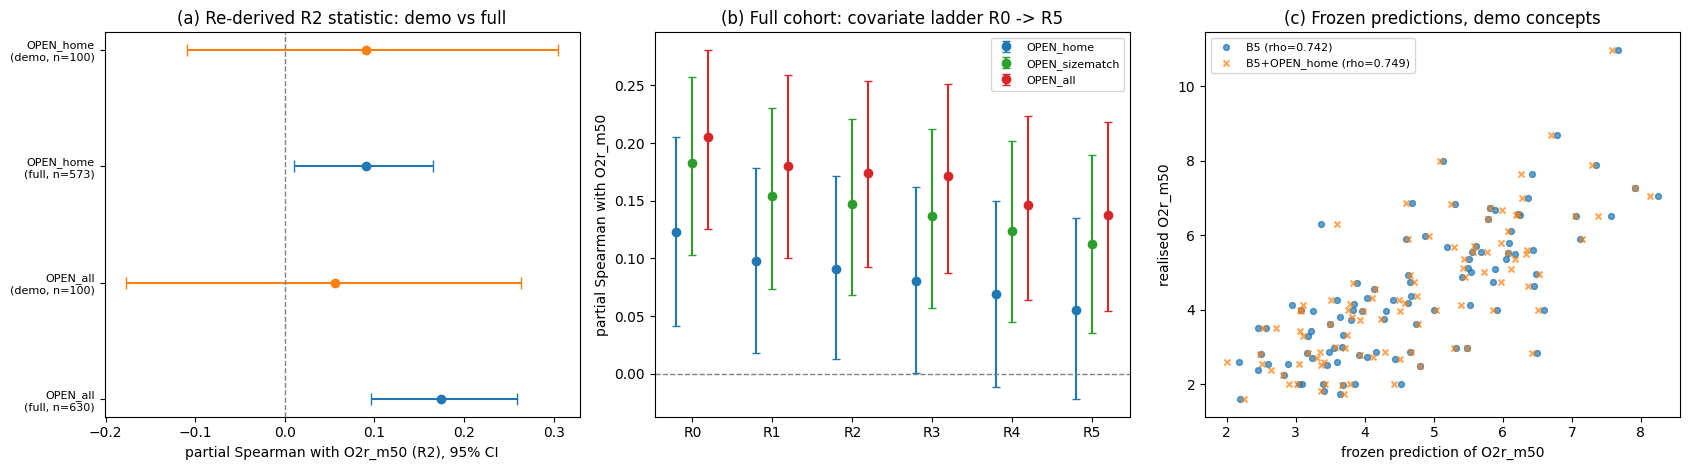

In [12]:
ref = data["full_cohort_reference"]
red = ref["rederive"]
rows = []
for b in ("home", "all"):
    k = f"OPEN_{b}_psp_R2"
    rows.append({"quantity": f"psp(OPEN_{b}, O2r_m50 | R2)",
                 "demo": f"{out[k]['est']:+.3f} [{out[k]['ci95_400boot'][0]:+.3f}, {out[k]['ci95_400boot'][1]:+.3f}]  n={out[k]['n']}",
                 "full cohort": f"{red[k]['est']:+.3f} [{red[k]['ci95_400boot'][0]:+.3f}, {red[k]['ci95_400boot'][1]:+.3f}]  n={red[k]['n']}"})
    rows.append({"quantity": f"OPEN_{b} rebuild max |diff|", "demo": f"{out[f'OPEN_{b}_max_abs_diff_vs_frozen_table']:.2e}",
                 "full cohort": f"{red[f'OPEN_{b}_max_abs_diff_vs_frozen_table']:.2e}"})
rows.append({"quantity": "placebo: shuffled-outcome q95 |psp|", "demo": f"{out['placebo_shuffled_outcome']['q95_abs']:.3f}",
             "full cohort": f"{red['placebo_shuffled_outcome']['q95_abs']:.3f}"})
rows.append({"quantity": "placebo: share |perm| >= |observed|", "demo": f"{out['placebo_shuffled_outcome']['share_ge_observed']:.3f}",
             "full cohort": f"{red['placebo_shuffled_outcome']['share_ge_observed']:.3f}"})
rows.append({"quantity": "placebo: random-OPEN psp", "demo": f"{out['placebo_random_open_psp']:+.3f}",
             "full cohort": f"{red['placebo_random_open_psp']:+.3f}"})
for m in ("B5", "B5_plus_OPEN_home", "diff"):
    rows.append({"quantity": f"prediction Spearman: {m}", "demo": f"{out['prediction_spearman'][m]:+.3f}",
                 "full cohort": f"{red['prediction_spearman'][m]:+.3f}"})
summary = pd.DataFrame(rows).set_index("quantity")
print("Frozen verdict (full cohort):", ref["verdict"])
print(summary.to_string())

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
# (a) R2 estimates, demo vs full
ax = axes[0]
labels, ests, los, his, cols = [], [], [], [], []
for b in ("home", "all"):
    k = f"OPEN_{b}_psp_R2"
    for src, dct, col in (("demo", out, "tab:orange"), ("full", red, "tab:blue")):
        labels.append(f"OPEN_{b}\n({src}, n={dct[k]['n']})")
        ests.append(dct[k]["est"]); los.append(dct[k]["ci95_400boot"][0]); his.append(dct[k]["ci95_400boot"][1]); cols.append(col)
yy = np.arange(len(labels))[::-1]
for yi, e, lo, hi, c in zip(yy, ests, los, his, cols):
    ax.errorbar(e, yi, xerr=[[e - lo], [hi - e]], fmt="o", color=c, capsize=4)
ax.axvline(0, color="grey", lw=1, ls="--")
ax.set_yticks(yy); ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("partial Spearman with O2r_m50 (R2), 95% CI")
ax.set_title("(a) Re-derived R2 statistic: demo vs full")

# (b) full-cohort ladder
ax = axes[1]
L = ref["primary_ladder"]
rungs = ["R0", "R1", "R2", "R3", "R4", "R5"]
for j, (b, c) in enumerate((("home", "tab:blue"), ("sizematch", "tab:green"), ("all", "tab:red"))):
    xs = np.arange(len(rungs)) + (j - 1) * 0.2
    r = [L[f"OPEN_{b}|O2r_m50|{g}"]["rho"] for g in rungs]
    lo = [L[f"OPEN_{b}|O2r_m50|{g}"]["ci"][0] for g in rungs]
    hi = [L[f"OPEN_{b}|O2r_m50|{g}"]["ci"][1] for g in rungs]
    ax.errorbar(xs, r, yerr=[np.subtract(r, lo), np.subtract(hi, r)], fmt="o", color=c, capsize=3, label=f"OPEN_{b}")
ax.axhline(0, color="grey", lw=1, ls="--")
ax.set_xticks(range(len(rungs))); ax.set_xticklabels(rungs)
ax.set_ylabel("partial Spearman with O2r_m50")
ax.set_title("(b) Full cohort: covariate ladder R0 -> R5")
ax.legend(fontsize=8)

# (c) frozen predictions vs outcome (demo concepts)
ax = axes[2]
ax.scatter(P.pred_b5, P.O2r_m50, s=18, alpha=0.7, label=f"B5 (rho={out['prediction_spearman']['B5']:.3f})")
ax.scatter(P.pred_b5_open, P.O2r_m50, s=18, alpha=0.7, marker="x",
           label=f"B5+OPEN_home (rho={out['prediction_spearman']['B5_plus_OPEN_home']:.3f})")
ax.set_xlabel("frozen prediction of O2r_m50"); ax.set_ylabel("realised O2r_m50")
ax.set_title("(c) Frozen predictions, demo concepts")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Reading the results

- **The OPEN rebuild is exact.** Rebuilding OPEN from the raw components with the frozen constants reproduces the stored
  values (max |diff| = 0), just as it does on the full cohort.
- **The point estimate matches, the sample is too small.** On 100 concepts, the `OPEN_home` R2 estimate is close to the
  full-cohort value, but its CI crosses 0. This is expected: in the full cohort the effect is only marginal
  (+0.091, CI lower bound +0.011, Holm p = 0.048), and it needs the full n = 573 to clear zero.
- **The ALL vs HOME gap needs the full cohort.** In the full cohort `OPEN_all` > `OPEN_sizematch` > `OPEN_home` at every
  rung of panel (b), because papers outside the home field feed back into the neighbourhood. A 100-concept sample is too
  noisy to show this ordering.
- **OPEN adds no practical prediction.** Adding `OPEN_home` to the frozen B5 model barely moves the prediction Spearman,
  both here and in the full cohort (0.768 → 0.770).
- To get the full-cohort numbers, run the original pipeline (`python method.py`, which needs the sealed data and the
  sibling run artifacts), or run `rederive.py` in the artifact folder on the full per-concept tables.